INFORMACIÓN GENERAL DEL DATASET
Dimensiones: (1000, 17)

Tipos de datos:
Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

Primeras filas:
    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7

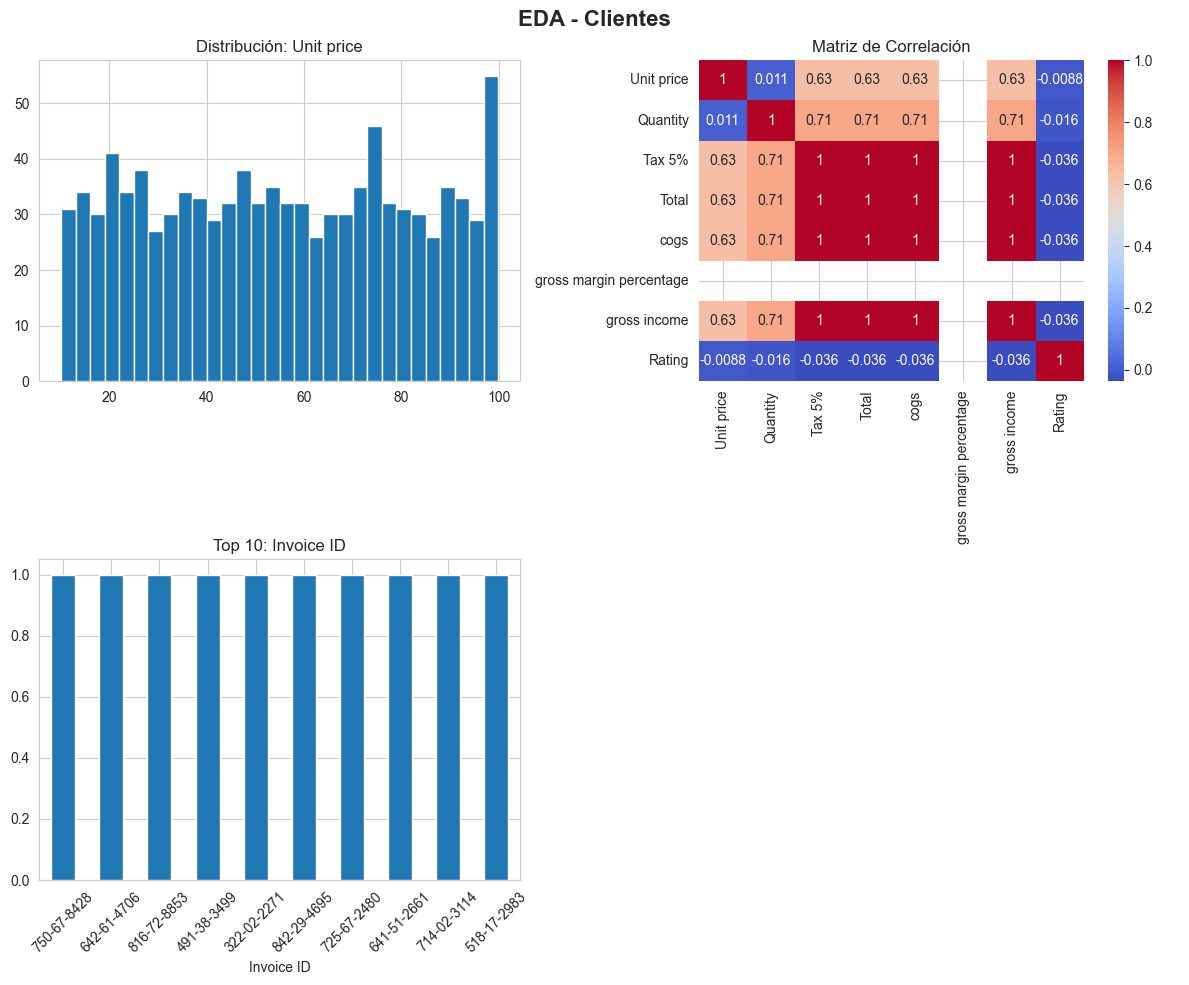

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Leer el archivo CSV
df = pd.read_csv('data/clientes.csv')

# Información básica del dataset
print("=" * 50)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 50)
print(f"Dimensiones: {df.shape}")
print(f"\nTipos de datos:\n{df.dtypes}")
print(f"\nPrimeras filas:\n{df.head()}")

# Estadísticas descriptivas
print("\n" + "=" * 50)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 50)
print(df.describe())

# Valores faltantes
print("\n" + "=" * 50)
print("VALORES FALTANTES")
print("=" * 50)
print(df.isnull().sum())
print(f"Porcentaje faltantes:\n{(df.isnull().sum() / len(df) * 100).round(2)}")

# Información de columnas categóricas
print("\n" + "=" * 50)
print("COLUMNAS CATEGÓRICAS")
print("=" * 50)
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df[col].value_counts())

# Visualizaciones
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("EDA - Clientes", fontsize=16, fontweight='bold')

# Distribucion de variables numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) > 0:
    df[numeric_cols[0]].hist(bins=30, ax=axes[0, 0])
    axes[0, 0].set_title(f"Distribución: {numeric_cols[0]}")

# Correlación
if len(numeric_cols) > 1:
    sns.heatmap(df[numeric_cols].corr(), annot=True, ax=axes[0, 1], cmap='coolwarm')
    axes[0, 1].set_title("Matriz de Correlación")

# Top categorías
categorical_cols = df.select_dtypes(include='object').columns.tolist()
if len(categorical_cols) > 0:
    df[categorical_cols[0]].value_counts().head(10).plot(kind='bar', ax=axes[1, 0])
    axes[1, 0].set_title(f"Top 10: {categorical_cols[0]}")
    axes[1, 0].tick_params(axis='x', rotation=45)

axes[1, 1].axis('off')
plt.tight_layout()
plt.show()